In [ ]:
# --- CELLA 1: SETUP AMBIENTE ---
import os, sys, yaml
import numpy as np
import torch
from IPython import get_ipython

PROJECT_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)
os.chdir(PROJECT_PATH)
print('Working dir:', os.getcwd())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('✅ Device:', device)

# Explainability (XAI) – RamanCNN (Integrated Gradients)
Questo notebook carica un esperimento già eseguito in `experiments/`, ricarica lo split salvato (`split_indices.npz`), carica i pesi (`best_weights.pth`) e salva le figure XAI in `output_dir/xai/`.

In [ ]:
# --- CELLA 2: SELEZIONA ESPERIMENTO (DA CONFIG) ---
# Metti qui il config dell'esperimento che vuoi spiegare:
config_file = os.environ.get('EXP_CONFIG_FILE', 'configs/classification/IBD/CNN/exp_01_cnn_baseline.yaml')
assert os.path.exists(config_file), f'Config non trovato: {config_file}'

# La cartella gemella in experiments/
output_dir = config_file.replace('configs', 'experiments').replace('.yaml', '')
assert os.path.isdir(output_dir), f'Esperimento non trovato (esegui prima training): {output_dir}'
print('Esperimento:', output_dir)

# Usa SEMPRE config_usato.yaml se presente (riproducibilità)
used_cfg_path = os.path.join(output_dir, 'config_usato.yaml')
cfg_path = used_cfg_path if os.path.exists(used_cfg_path) else config_file
with open(cfg_path, 'r') as f:
    config = yaml.safe_load(f)
print('✅ Config usato:', cfg_path)


Esperimento: /content/drive/Othercomputers/Il mio laptop/SpectraBreast/experiments/classification/IBD/CNN/exp_01_cnn_baseline
✅ Config usato: /content/drive/Othercomputers/Il mio laptop/SpectraBreast/experiments/classification/IBD/CNN/exp_01_cnn_baseline/config_usato.yaml


In [13]:
# --- CELLA 3: CARICA SPLIT + DATASET ---
import h5py
import scipy.io as sio

split_path = os.path.join(output_dir, 'split_indices.npz')
assert os.path.exists(split_path), f'Split indices non trovati: {split_path}'
spl = np.load(split_path, allow_pickle=True)
idx_train = spl['idx_train']
idx_val = spl['idx_val']
idx_test = spl['idx_test']

dataset_path = config['dataset']['path']
assert os.path.exists(dataset_path), f'Dataset non trovato: {dataset_path}'

x_axis = None
try:
    with h5py.File(dataset_path, 'r') as f:
        X_data = np.array(f['X_processed'])
        Y_data = np.array(f['labels_binary']).flatten().astype(np.int64)
        for key in ('asse_target', 'x_axis', 'axis', 'wavenumbers'):
            if key in f.keys():
                x_axis = np.array(f[key]).flatten()
                break
except (OSError, NotImplementedError):
    data = sio.loadmat(dataset_path)
    X_data = data['X_processed'].astype(np.float32)
    Y_data = data['labels_binary'].flatten().astype(np.int64)
    for key in ('asse_target', 'x_axis', 'axis', 'wavenumbers'):
        if key in data:
            x_axis = np.array(data[key]).flatten()
            break

if X_data.shape[0] == 500 and X_data.shape[1] == len(Y_data):
    X_data = X_data.T
X_data = X_data.astype(np.float32)
N, L = X_data.shape

if x_axis is None or len(x_axis) != L:
    x_axis = np.arange(L, dtype=np.float32)
else:
    x_axis = x_axis.astype(np.float32)

X_test = X_data[idx_test]
y_test = Y_data[idx_test]
Xte = torch.from_numpy(X_test).unsqueeze(1).float().to(device)
yte = torch.from_numpy(y_test).long().to(device)
print(f'✅ Dataset caricato. Test set: {len(y_test)} campioni | L={L}')

✅ Dataset caricato. Test set: 35 campioni | L=500


In [14]:
# --- CELLA 4: CARICA MODELLO + PESI ---
model_arch = config.get('model', {}).get('architecture', 'RamanCNN')
assert model_arch in ('RamanCNN', 'CNN'), f'Architettura non supportata qui: {model_arch}'

from src.models.cnn.raman_cnn_01 import RamanCNN
model = RamanCNN(input_length=int(config['model']['input_length']), n_classes=int(config['model']['n_classes'])).to(device)

weights_path = os.path.join(output_dir, 'best_weights_holdout.pth')
assert os.path.exists(weights_path), f'Pesi non trovati: {weights_path}'
state = torch.load(weights_path, map_location=device)
model.load_state_dict(state)
model.eval()
print('✅ Pesi caricati:', weights_path)


✅ Pesi caricati: /content/drive/Othercomputers/Il mio laptop/SpectraBreast/experiments/classification/IBD/CNN/exp_01_cnn_baseline/best_weights.pth


Selected test indices (within test set): [1, 0]


/tmp/ipykernel_2088/1070070034.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


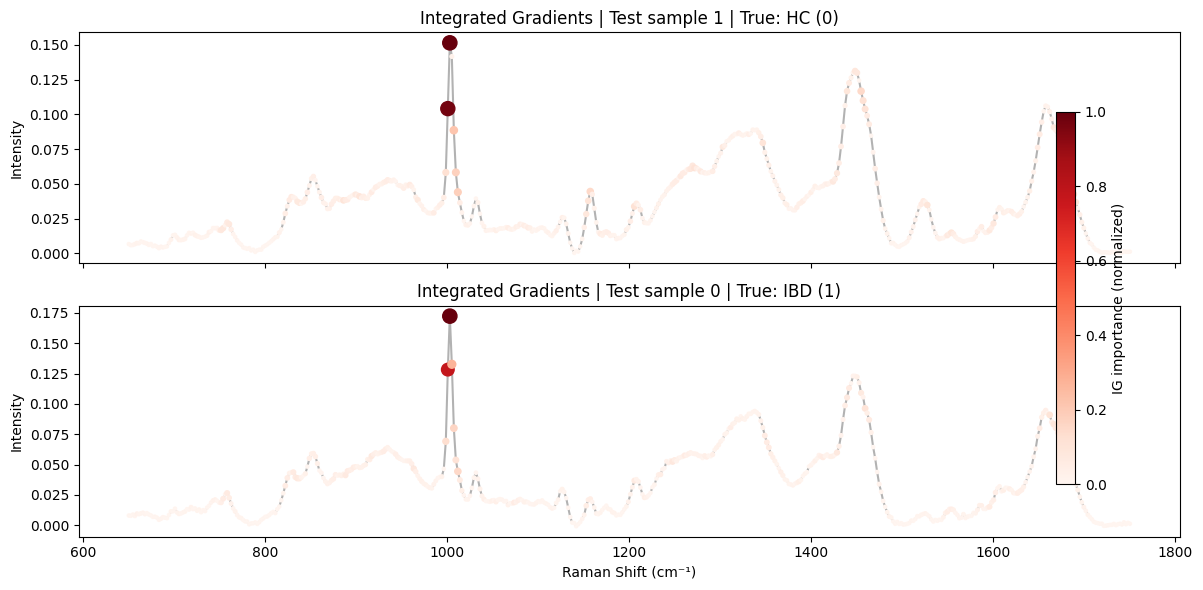

✅ Salvato: /content/drive/Othercomputers/Il mio laptop/SpectraBreast/experiments/classification/IBD/CNN/exp_01_cnn_baseline/xai/ig_samples.png


In [15]:
# --- CELLA 5: XAI (Integrated Gradients) - Campioni singoli ---
import matplotlib.pyplot as plt
from src.xai.integrated_gradients_1d import integrated_gradients_1d

xai_dir = os.path.join(output_dir, 'xai')
os.makedirs(xai_dir, exist_ok=True)

with torch.no_grad():
    logits = model(Xte)
    preds = logits.argmax(dim=1).detach().cpu().numpy()
labels = y_test

# Prendi 1 HC corretto e 1 IBD corretto (se esistono)
hc_candidates = np.where((labels == 0) & (preds == 0))[0]
ibd_candidates = np.where((labels == 1) & (preds == 1))[0]
selected = []
if len(hc_candidates) > 0:
    selected.append(int(hc_candidates[0]))
if len(ibd_candidates) > 0:
    selected.append(int(ibd_candidates[0]))
if len(selected) == 0:
    selected = [0]
print('Selected test indices (within test set):', selected)

steps = 50
fig, axes = plt.subplots(len(selected), 1, figsize=(12, 3 * len(selected)), sharex=True)
if len(selected) == 1:
    axes = [axes]

for ax, i in zip(axes, selected):
    x = Xte[i:i+1]
    true_label = int(labels[i])
    ig = integrated_gradients_1d(model, x, target_class_idx=true_label, steps=steps)
    ig = ig.squeeze().detach().cpu().numpy()
    spectrum = x.squeeze().detach().cpu().numpy()
    ig_abs = np.abs(ig)
    ig_norm = (ig_abs - ig_abs.min()) / (ig_abs.max() - ig_abs.min() + 1e-8)
    ax.plot(x_axis, spectrum, color='gray', alpha=0.6)
    sc = ax.scatter(x_axis, spectrum, c=ig_norm, cmap='Reds', s=ig_norm * 100 + 5, zorder=5)
    lab = 'HC (0)' if true_label == 0 else 'IBD (1)'
    ax.set_title(f'Integrated Gradients | Test sample {i} | True: {lab}')
    ax.set_ylabel('Intensity')
axes[-1].set_xlabel('Raman Shift (cm⁻¹)')
cbar = fig.colorbar(sc, ax=axes, fraction=0.02, pad=0.02)
cbar.set_label('IG importance (normalized)')

fig.tight_layout()
fig_path = os.path.join(xai_dir, 'ig_samples.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print('✅ Salvato:', fig_path)

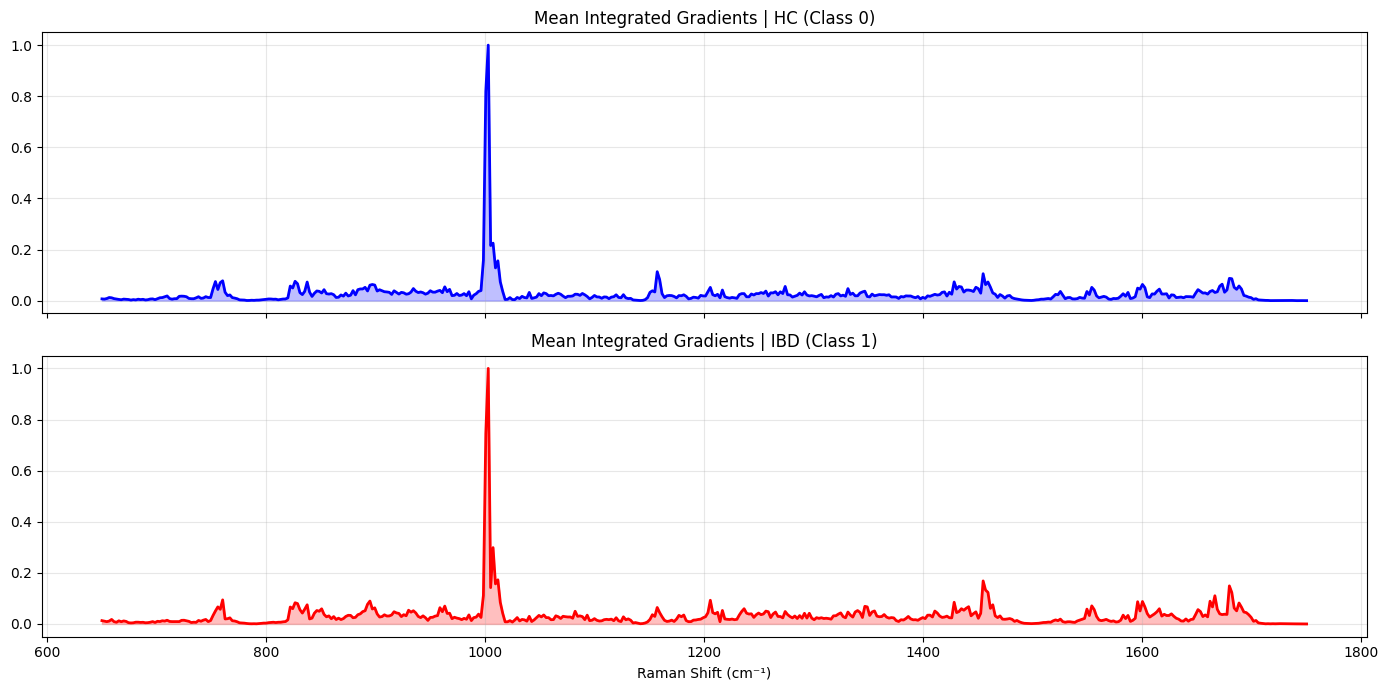

✅ Salvato: /content/drive/Othercomputers/Il mio laptop/SpectraBreast/experiments/classification/IBD/CNN/exp_01_cnn_baseline/xai/ig_mean_per_class.png


In [16]:
# --- CELLA 6: XAI (Integrated Gradients) - Profilo medio per classe (veloce) ---
import matplotlib.pyplot as plt
from src.xai.integrated_gradients_1d import integrated_gradients_1d

# Per velocità: campiona al massimo N esempi per classe
MAX_PER_CLASS = 50
steps = 25

idx_hc = np.where(y_test == 0)[0]
idx_ibd = np.where(y_test == 1)[0]
if len(idx_hc) > MAX_PER_CLASS:
    idx_hc = idx_hc[:MAX_PER_CLASS]
if len(idx_ibd) > MAX_PER_CLASS:
    idx_ibd = idx_ibd[:MAX_PER_CLASS]

def mean_abs_ig(indices, target_class):
    vals = []
    for i in indices:
        x = Xte[int(i):int(i)+1]
        ig = integrated_gradients_1d(model, x, target_class_idx=int(target_class), steps=steps)
        vals.append(np.abs(ig.squeeze().detach().cpu().numpy()))
    if len(vals) == 0:
        return None
    arr = np.stack(vals, axis=0)
    m = arr.mean(axis=0)
    m = (m - m.min()) / (m.max() - m.min() + 1e-8)
    return m

ig_hc = mean_abs_ig(idx_hc, target_class=0)
ig_ibd = mean_abs_ig(idx_ibd, target_class=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
if ig_hc is not None:
    axes[0].plot(x_axis, ig_hc, color='blue', linewidth=2)
    axes[0].fill_between(x_axis, 0, ig_hc, color='blue', alpha=0.25)
axes[0].set_title('Mean Integrated Gradients | HC (Class 0)')
axes[0].grid(alpha=0.3)

if ig_ibd is not None:
    axes[1].plot(x_axis, ig_ibd, color='red', linewidth=2)
    axes[1].fill_between(x_axis, 0, ig_ibd, color='red', alpha=0.25)
axes[1].set_title('Mean Integrated Gradients | IBD (Class 1)')
axes[1].set_xlabel('Raman Shift (cm⁻¹)')
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig_path = os.path.join(xai_dir, 'ig_mean_per_class.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print('✅ Salvato:', fig_path)

In [ ]:
# --- CELLA 7: TABELLA TOP 5 PICCHI ---
import pandas as pd

top_n = 5

def get_unique_top_bands(ig_array, x_axis_arr, top_n=5, min_dist=15):
    if ig_array is None: return []
    idx_sorted = np.argsort(ig_array)[::-1]
    unique_bands = []
    for idx in idx_sorted:
        shift = x_axis_arr[idx]
        if all(abs(shift - b[0]) > min_dist for b in unique_bands):
            unique_bands.append((shift, ig_array[idx]))
        if len(unique_bands) == top_n:
            break
    return unique_bands

peaks_hc = get_unique_top_bands(ig_hc, x_axis, top_n)
peaks_ibd = get_unique_top_bands(ig_ibd, x_axis, top_n)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].axis('off')
axes[1].axis('off')

if len(peaks_hc) > 0:
    df_hc = pd.DataFrame(peaks_hc, columns=["Wavenumber (cm⁻¹)", "Importance"]).round(4)
    table_hc = axes[0].table(cellText=df_hc.values, colLabels=df_hc.columns, loc='center', cellLoc='center')
    table_hc.auto_set_font_size(False)
    table_hc.set_fontsize(12)
    table_hc.scale(1, 1.5)
    axes[0].set_title(f"Top {top_n} Peaks - HC (Class 0)", fontweight="bold")
    
if len(peaks_ibd) > 0:
    df_ibd = pd.DataFrame(peaks_ibd, columns=["Wavenumber (cm⁻¹)", "Importance"]).round(4)
    table_ibd = axes[1].table(cellText=df_ibd.values, colLabels=df_ibd.columns, loc='center', cellLoc='center')
    table_ibd.auto_set_font_size(False)
    table_ibd.set_fontsize(12)
    table_ibd.scale(1, 1.5)
    axes[1].set_title(f"Top {top_n} Peaks - IBD (Class 1)", fontweight="bold")
    
plt.tight_layout()
fig_path_table = os.path.join(xai_dir, 'ig_top5_peaks_table.png')
plt.savefig(fig_path_table, dpi=150, bbox_inches='tight')
plt.show()
print('✅ Tabella Top Peaks salvata in:', fig_path_table)


